In [7]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.graph_color import color_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian
from copy import copy
from koala.lattice import INVALID
from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)
from tqdm import tqdm

import matplotlib as mpl
from collections import Counter

from dimer_models.kasteleyn import find_kasteleyn_number, find_local_dimer_probability

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


mpl.rcParams.update(
    {
        "font.size": 11,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)

import pickle

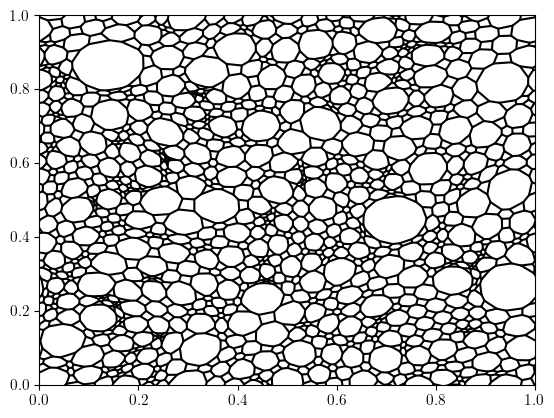

In [ ]:
lattice = bipartite_squarefull(3000)


pl.plot_edges(lattice)

probs = find_local_dimer_probability(lattice)
adj_plaquettes = lattice.edges.adjacent_plaquettes
n_sides = np.array([p.n_sides for p in lattice.plaquettes])
curvature = -1 / 3 + np.sum(1 / n_sides[adj_plaquettes], axis=1)

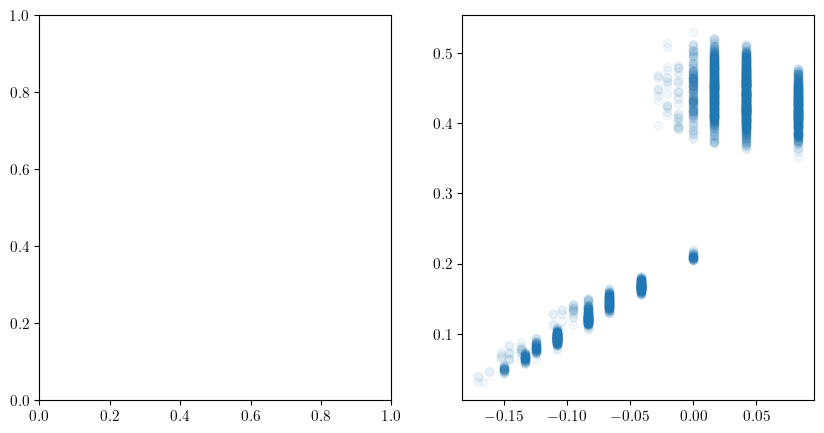

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plt.scatter(curvature, probs, alpha=0.05)

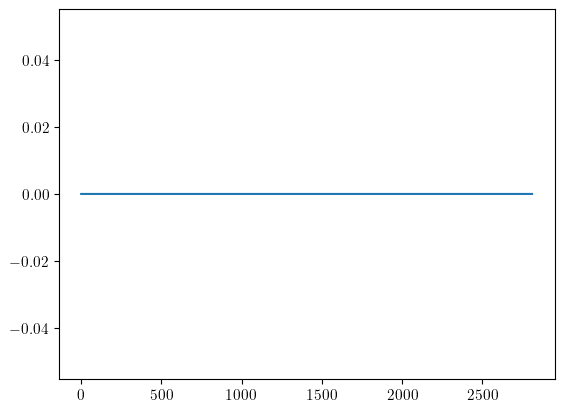

In [10]:
lattice

n_sides = np.array([p.n_sides for p in lattice.plaquettes])
adj_plaqs = lattice.vertices.adjacent_plaquettes
adj_sides = n_sides[adj_plaqs]
vertex_curvature = np.sum(1 / adj_sides, axis=1) - 0.5

adjacent_bipartiteness = np.sum(adj_sides % 2, axis=1)


plt.plot(adjacent_bipartiteness)